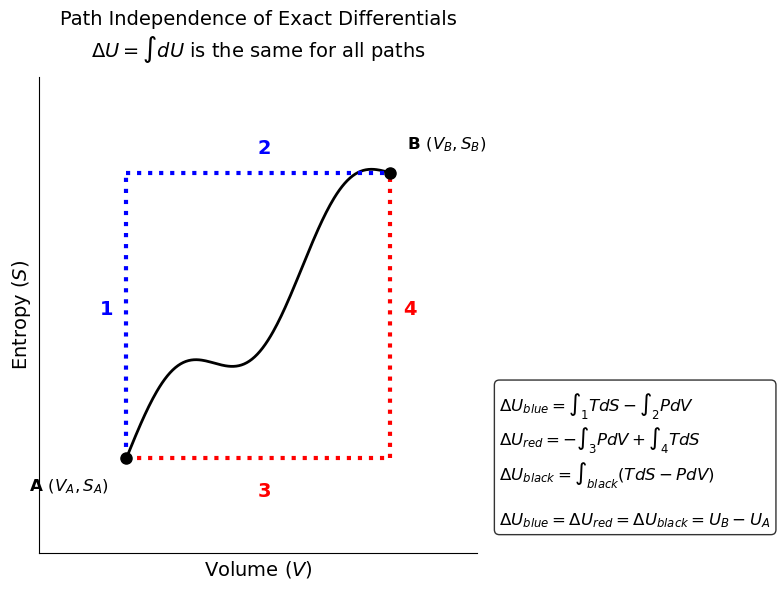

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the coordinates for points A and B
V_A, S_A = 1.0, 1.0
V_B, S_B = 4.0, 4.0

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# ---------------------------------------------------------
# 1. The Squiggly Black Line (Arbitrary Path)
# ---------------------------------------------------------
# Create a linear path and add a sine wave to make it "squiggly"
v_squiggly = np.linspace(V_A, V_B, 200)
# Linear interpolation for the base line
s_linear = np.interp(v_squiggly, [V_A, V_B], [S_A, S_B])
# Add a sinusoidal perturbation
s_squiggly = s_linear + 0.4 * np.sin(3 * np.pi * (v_squiggly - V_A) / (V_B - V_A))

ax.plot(v_squiggly, s_squiggly, 'k-', linewidth=2, label='Arbitrary Path')

# ---------------------------------------------------------
# 2. The Blue Dotted Path (Constant V, then Constant S)
# ---------------------------------------------------------
# Path 1: (V_A, S_A) to (V_A, S_B)
ax.plot([V_A, V_A], [S_A, S_B], 'b:', linewidth=3)
# Path 2: (V_A, S_B) to (V_B, S_B)
ax.plot([V_A, V_B], [S_B, S_B], 'b:', linewidth=3)

# Labels for blue path
ax.text(V_A - 0.15, (S_A + S_B)/2, '1', color='blue', fontsize=14, fontweight='bold', ha='right')
ax.text((V_A + V_B)/2, S_B + 0.15, '2', color='blue', fontsize=14, fontweight='bold', va='bottom')

# ---------------------------------------------------------
# 3. The Red Dotted Path (Constant S, then Constant V)
# ---------------------------------------------------------
# Path 3: (V_A, S_A) to (V_B, S_A)
ax.plot([V_A, V_B], [S_A, S_A], 'r:', linewidth=3)
# Path 4: (V_B, S_A) to (V_B, S_B)
ax.plot([V_B, V_B], [S_A, S_B], 'r:', linewidth=3)

# Labels for red path
ax.text((V_A + V_B)/2, S_A - 0.25, '3', color='red', fontsize=14, fontweight='bold', va='top')
ax.text(V_B + 0.15, (S_A + S_B)/2, '4', color='red', fontsize=14, fontweight='bold', ha='left')

# ---------------------------------------------------------
# 4. Markers and Annotations for Points A and B
# ---------------------------------------------------------
# Plot the points
ax.plot([V_A, V_B], [S_A, S_B], 'ko', markersize=8, zorder=5)

# Label the points
ax.text(V_A - 0.2, S_A - 0.2, 'A $(V_A, S_A)$', fontsize=12, fontweight='bold', ha='right', va='top')
ax.text(V_B + 0.2, S_B + 0.2, 'B $(V_B, S_B)$', fontsize=12, fontweight='bold', ha='left', va='bottom')

# ---------------------------------------------------------
# 5. Formatting the Plot
# ---------------------------------------------------------
# Add titles and axis labels
ax.set_title('Path Independence of Exact Differentials\n$\\Delta U = \\int dU$ is the same for all paths', fontsize=14, pad=15)
ax.set_xlabel('Volume ($V$)', fontsize=14)
ax.set_ylabel('Entropy ($S$)', fontsize=14)

# Set limits to give some breathing room
ax.set_xlim(V_A - 1, V_B + 1)
ax.set_ylim(S_A - 1, S_B + 1)

# Remove the top and right spines for a cleaner, textbook-style look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove numeric ticks to keep it purely conceptual
ax.set_xticks([])
ax.set_yticks([])

# Add a text box explaining the math
math_text = (
    "$\\Delta U_{blue} = \\int_{1} T dS - \\int_{2} P dV$\n"
    "$\\Delta U_{red} = -\\int_{3} P dV + \\int_{4} T dS$\n"
    "$\\Delta U_{black} = \\int_{black} (T dS - P dV)$\n\n"
    "$\\Delta U_{blue} = \\Delta U_{red} = \\Delta U_{black} = U_B - U_A$"
)
ax.text(1.05, 0.05, math_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()